In [2]:
import numpy as np

from scipy.special import comb as n_choose_k
from sklearn.linear_model import LogisticRegression
from scipy.stats import pearsonr, spearmanr
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)


import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm

from itertools import combinations
from collections import defaultdict
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda')
device

from data import *

In [3]:
# Parameters
seed = 7012025
C = np.inf # no regularisation for lin. regression
power = 1 # uniform density
D = 1000 # number of data samples
N = 100 # number of sources
K = 10 # sparsity
num_ood = N // 2 # how many new OOD sources
M = int(np.ceil(K * np.log(N / K) * 1)) # Compressed Sensing bound
num_ood, M

(50, 24)

# Game Plan

### IID means either:

a) first index and any of the IID distractors [cow and grass]

b) NOT the first index and ANY of the distractors [grass and sand]

### OOD means:

c) first index and any of the OOD distractors [cow and sand]

In [97]:
# # sampling functions

# def sample_comb(ind, N=N, K=K, power=power):
#     """given K indices, sample sources"""
#     z = np.zeros(N)
#     z[ind] = np.random.uniform(0, 1, K) ** power
#     return z

# def sample_setting_a(seed=None, N=N, K=K, num_ood=num_ood):
#     """include first index and sample randomly from IID"""
#     if seed is not None:
#         np.random.seed(seed)
#     ind_distractors = np.random.choice(
#         np.arange(1, N - num_ood), K - 1, replace=False)
#     # add first latent
#     ind = np.concatenate([np.zeros(1, dtype=int), ind_distractors])
#     z = sample_comb(ind, N=N, K=K)
#     return z

# def sample_setting_b(seed=None, N=N, K=K, num_ood=num_ood):
#     """sample randomly from all but first"""
#     if seed is not None:
#         np.random.seed(seed)
#     ind = np.random.choice(np.arange(1, N), K, replace=False)
#     z = sample_comb(ind, N=N, K=K)
#     return z

# def sample_setting_c(seed=None, N=N, K=K, num_ood=num_ood):
#     """include first index and sample randomly from OOD"""
#     if seed is not None:
#         np.random.seed(seed)
#     ind_distractors = np.random.choice(
#         np.arange(N - num_ood, N), K - 1, replace=False)
#     # add first latent
#     ind = np.concatenate([np.zeros(1, dtype=int), ind_distractors])
#     z = sample_comb(ind, N=N, K=K)
#     return z

# def sample_iid(seed=None, N=N, K=K, num_ood=num_ood):
#     """only sample from IID latent combinations"""
#     if seed is not None:
#         np.random.seed(seed)
#     # is variable of interest in sample?
#     first_one_in = np.random.binomial(n=1, p=.5)
#     if first_one_in: # a) setting
#         return sample_setting_a(seed=None, N=N, K=K, num_ood=num_ood)
#     else: # b) setting
#         return sample_setting_b(seed=None, N=N, K=K, num_ood=num_ood)

# def sample_ood(seed=None, N=N, K=K, num_ood=num_ood):
#     return sample_setting_c(seed=None, N=N, K=K, num_ood=num_ood)

# def sample_all(seed=None, N=N, K=K):
#     """no IID/OOD split, just sample all"""
#     if seed is not None:
#         np.random.seed(seed)
#     ind = np.random.choice(np.arange(N), K, replace=False)
#     z = sample_comb(ind, N=N, K=K)
#     return z

In [4]:
sample_setting_c(N=N, K=K)

array([0.23523906, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.77783968, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.99482601, 0.07642536,
       0.77190622, 0.        , 0.18444662, 0.        , 0.46882

In [5]:
# Full example: train encoder with matrix A...

In [6]:
# lazy example (might not be perfect), just draw random A
np.random.seed(seed)
# https://en.wikipedia.org/wiki/Restricted_isometry_property
A = np.random.normal(0, 1, (M, N)) # random normal has RIP -> CS works =)
A /= np.linalg.norm(A, axis=0, keepdims=True)
A.min(), A.max(), A.shape

(np.float64(-0.6458119825139067), np.float64(0.6527911931680838), (24, 100))

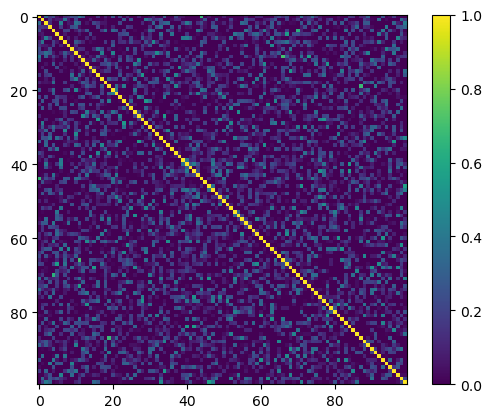

In [7]:
plt.imshow(A.T @ A, vmin=0, vmax=1, cmap='viridis')
plt.colorbar()

In [8]:
# generate data
np.random.seed(seed)

Z_iid = np.array([sample_iid(N=N, K=K) for _ in range(D)])
Y_iid = Z_iid @ A.T
label_iid = Z_iid[:, 0] > .5

Z_ood = np.array([sample_ood(N=N, K=K) for _ in range(D)])
Y_ood = Z_ood @ A.T
label_ood = Z_ood[:, 0] > .5

Z_iid.shape, Y_iid.shape, label_iid[:10], np.mean(label_iid)

((1000, 100),
 (1000, 24),
 array([False, False, False, False, False, False,  True, False, False,
        False]),
 np.float64(0.237))

In [9]:
# test linear probe
clf = LogisticRegression(C=C).fit(Z_iid, label_iid)

acc_iid = clf.score(Z_iid, label_iid)
acc_ood = clf.score(Z_ood, label_ood)
print(f'In source (Z) space: acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

clf = LogisticRegression(C=C).fit(Y_iid, label_iid)

acc_iid = clf.score(Y_iid, label_iid)
acc_ood = clf.score(Y_ood, label_ood)
print(f'In observation (Y=AZ) space: acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

In source (Z) space: acc IID: 1.000, acc OOD: 0.950
In observation (Y=AZ) space: acc IID: 0.889, acc OOD: 0.596


In [10]:
# 1. Pick device
device = torch.device('cuda')

# 2. Convert the NumPy arrays to torch tensors:
#    - inputs: size (D, M)
#    - targets: size (D, N)
inputs_iid  = torch.tensor(Y_iid, dtype=torch.float32, device=device)
targets_iid = torch.tensor(Z_iid, dtype=torch.float32, device=device)

# set up OOD split for evaluation:
inputs_ood  = torch.tensor(Y_ood, dtype=torch.float32, device=device)
targets_ood = torch.tensor(Z_ood, dtype=torch.float32, device=device)

# 3. Wrap them in a DataLoader for mini-batch training:
batch_size = 64  
train_ds = TensorDataset(inputs_iid, targets_iid)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

# 4. Redefine SAE model for dimensions M→N (N > M):
#    Here M is the compressed sensing measurement dim,
#    and N is the sparse source dim.
encoder = torch.nn.Sequential(torch.nn.Linear(M, N),torch.nn.Softplus()).to(device)
decoder = torch.nn.Linear(N, M).to(device) 

# 5. Set up optimizer and loss
optim = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()),lr=1e-3)
mse_loss = torch.nn.MSELoss() # returns scalar value of all mse's between input and target

lambda_l1 = 1e-1

In [11]:
def reset_and_reinit(encoder, decoder, lr=1e-3):
    # 1) reset all layer weights
    for module in (encoder, decoder):
        module.apply(lambda m: m.reset_parameters()
                                  if hasattr(m, 'reset_parameters') else None)

    # 2) return a brand-new optimizer so there’s no leftover momentum
    return encoder, decoder, torch.optim.Adam(
        list(encoder.parameters()) + list(decoder.parameters()),
        lr=lr
    )



In [ ]:
encoder, decoder, optim = reset_and_reinit(encoder, decoder, lr=1e-3)

num_epochs = 10 # try for multiple epochs 
# Supervised training
for epoch in range(num_epochs):
    for X_batch, Z_batch in train_loader: 
        optim.zero_grad()
        Z_pred = encoder(X_batch)
        loss_sup = mse_loss(Z_pred, Z_batch)
        loss_sup.backward()
        optim.step()
    with torch.no_grad():
        train_loss = mse_loss(encoder(inputs_iid), targets_iid)
    print(f"[Sup] Epoch {epoch+1}, MSE: {train_loss:.4f}") 

# since we have the true latents, we can measure how similar the estimated is to the ground truth latent

[Sup] Epoch 1, MSE: 0.4402
[Sup] Epoch 2, MSE: 0.4121
[Sup] Epoch 3, MSE: 0.3866
[Sup] Epoch 4, MSE: 0.3636
[Sup] Epoch 5, MSE: 0.3429
[Sup] Epoch 6, MSE: 0.3241
[Sup] Epoch 7, MSE: 0.3070
[Sup] Epoch 8, MSE: 0.2915
[Sup] Epoch 9, MSE: 0.2774
[Sup] Epoch 10, MSE: 0.2644


In [16]:
encoder, decoder, optim = reset_and_reinit(encoder, decoder, lr=1e-2)

num_epochs = 100 # try for multiple epochs 
# Unsupervised training
for epoch in range(num_epochs):
    for X_batch, _ in train_loader:
        optim.zero_grad()
        Z_pred = encoder(X_batch)                 # encode
        X_rec  = decoder(Z_pred)                  # decode
        loss_rec = mse_loss(X_rec, X_batch)       # reconstruction Mean Squared Error
        # l1_pen   = torch.mean(torch.abs(Z_pred))  # average ℓ₁ norm in the code, keeps the code sparse
        l1_pen = torch.mean(torch.abs(Z_pred) * torch.linalg.norm(decoder.weight, dim=0)) 
        loss = loss_rec + lambda_l1 * l1_pen
        loss.backward()
        optim.step()

    # Evaluate on IID & OOD
    encoder.eval(); decoder.eval()
    with torch.no_grad():
        # IID
        Z_i = encoder(inputs_iid)
        X_i = decoder(Z_i)
        rec_i  = mse_loss(X_i, inputs_iid).item()
        l1_i   = torch.mean(torch.abs(Z_i)).item()
        total_i = rec_i + lambda_l1 * l1_i

        # OOD
        Z_o = encoder(inputs_ood)
        X_o = decoder(Z_o)
        rec_o  = mse_loss(X_o, inputs_ood).item()
        l1_o   = torch.mean(torch.abs(Z_o)).item()
        total_o = rec_o + lambda_l1 * l1_o

    print(f"[Epoch {epoch:2d}] IID Loss: {total_i:.4f} (rec {rec_i:.4f}, l1 {l1_i:.4f})   "
          f"OOD Loss: {total_o:.4f} (rec {rec_o:.4f}, l1 {l1_o:.4f})")

# Final Z reconstructions
with torch.no_grad():
    Z_rec_iid = encoder(inputs_iid)  # (D, N)
    Z_rec_ood = encoder(inputs_ood)  # (D, N)

# convert to NumPy
Z_rec_iid_np = Z_rec_iid.cpu().numpy()
Z_rec_ood_np = Z_rec_ood.cpu().numpy()

print("Shapes:", Z_rec_iid_np.shape, Z_rec_ood_np.shape)

# plot the loss after: if you decrease the learning rate and increase the batch size, you can get smoother transitions
# want to go down as much as possible 
# increase the number of epochs, adjust the learning rate

# also evaluate on the downstream task

# rename and commit to project443334



[Epoch  0] IID Loss: 0.1626 (rec 0.0995, l1 0.6315)   OOD Loss: 0.1900 (rec 0.1269, l1 0.6314)
[Epoch  1] IID Loss: 0.1067 (rec 0.0448, l1 0.6195)   OOD Loss: 0.1137 (rec 0.0517, l1 0.6201)
[Epoch  2] IID Loss: 0.0853 (rec 0.0222, l1 0.6307)   OOD Loss: 0.0922 (rec 0.0290, l1 0.6314)
[Epoch  3] IID Loss: 0.0757 (rec 0.0118, l1 0.6392)   OOD Loss: 0.0808 (rec 0.0167, l1 0.6407)
[Epoch  4] IID Loss: 0.0712 (rec 0.0071, l1 0.6409)   OOD Loss: 0.0749 (rec 0.0105, l1 0.6440)
[Epoch  5] IID Loss: 0.0685 (rec 0.0046, l1 0.6394)   OOD Loss: 0.0706 (rec 0.0062, l1 0.6437)
[Epoch  6] IID Loss: 0.0669 (rec 0.0032, l1 0.6367)   OOD Loss: 0.0691 (rec 0.0049, l1 0.6421)
[Epoch  7] IID Loss: 0.0659 (rec 0.0026, l1 0.6327)   OOD Loss: 0.0677 (rec 0.0038, l1 0.6390)
[Epoch  8] IID Loss: 0.0651 (rec 0.0023, l1 0.6284)   OOD Loss: 0.0668 (rec 0.0033, l1 0.6354)
[Epoch  9] IID Loss: 0.0645 (rec 0.0021, l1 0.6237)   OOD Loss: 0.0660 (rec 0.0029, l1 0.6313)
[Epoch 10] IID Loss: 0.0640 (rec 0.0020, l1 0.6197

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def make_dataloaders(Y, Z, batch_size):
    ds = TensorDataset(torch.tensor(Y, dtype=torch.float32),
                       torch.tensor(Z, dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=True)

def build_model(M, N):
    enc = torch.nn.Sequential(
        torch.nn.Linear(M, N),
        torch.nn.Softplus()
    ).to(device)
    dec = torch.nn.Linear(N, M).to(device)
    return enc, dec

def reset_and_reinit(encoder, decoder, lr):
    # reinit weights and re‐build optimizer
    for m in encoder.modules():
        if hasattr(m, 'reset_parameters'):
            m.reset_parameters()
    for m in decoder.modules():
        if hasattr(m, 'reset_parameters'):
            m.reset_parameters()
    opt = torch.optim.Adam(list(encoder.parameters()) +
                           list(decoder.parameters()), lr=lr)
    return encoder, decoder, opt

In [10]:
mse_loss = torch.nn.MSELoss()
lambda_l1 = 1e-1

# --- hyperparameter grids:
learning_rates = [1e-2, 1e-3, 1e-4]
batch_sizes    = [32, 64]
num_epochs_list= [10, 20]

# assume Y_iid, Z_iid are your numpy arrays of shape (D, M)/(D, N)
# and M, N variables exist in your scope
results = {}  # (lr, bs, epochs) -> list of epoch losses

for lr in learning_rates:
    for bs in batch_sizes:
        # build fresh model per bs/lr combo
        enc, dec = build_model(M, N)
        enc, dec, optim = reset_and_reinit(enc, dec, lr)
        loader = make_dataloaders(Y_iid, Z_iid, bs)

        for epochs in num_epochs_list:
            key = (lr, bs, epochs)
            epoch_losses = []
            # re‐reset before each new epoch‐count run
            enc, dec, optim = reset_and_reinit(enc, dec, lr)

            for epoch in range(epochs):
                enc.train(); dec.train()
                running = 0.0
                count   = 0
                for X_batch, _ in loader:
                    Xb = X_batch.to(device)
                    optim.zero_grad()
                    Zp = enc(Xb)
                    Xr = dec(Zp)
                    loss_rec = mse_loss(Xr, Xb)
                    l1_pen   = torch.mean(
                        torch.abs(Zp) * torch.linalg.norm(dec.weight, dim=0)
                    )
                    loss = loss_rec + lambda_l1 * l1_pen
                    loss.backward()
                    optim.step()
                    running += loss_rec.item() * Xb.size(0)
                    count   += Xb.size(0)
                epoch_losses.append(running / count)  # avg reconstruction loss
            results[key] = epoch_losses


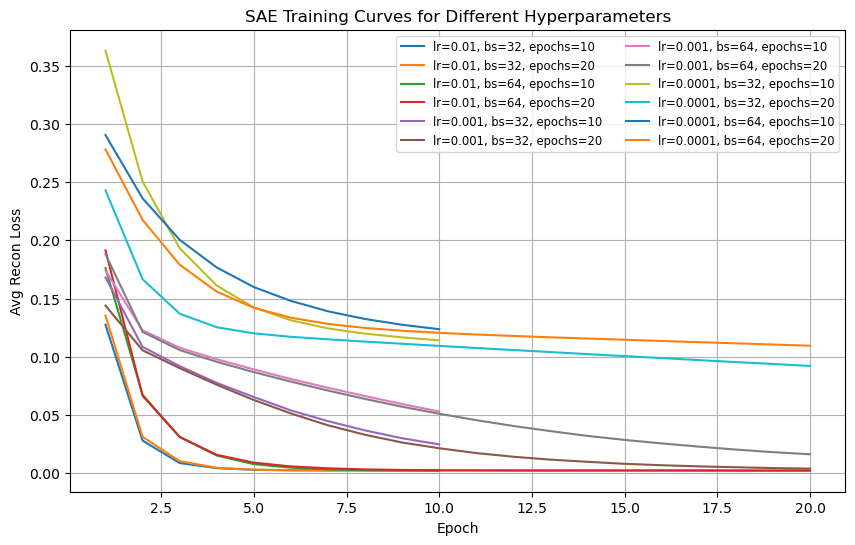

In [11]:
# --- plotting:
plt.figure(figsize=(10, 6))
for (lr, bs, epochs), losses in results.items():
    label = f"lr={lr}, bs={bs}, epochs={epochs}"
    plt.plot(range(1, len(losses)+1), losses, label=label)
plt.xlabel("Epoch")
plt.ylabel("Avg Recon Loss")
plt.title("SAE Training Curves for Different Hyperparameters")
plt.legend(fontsize="small", ncol=2)
plt.grid(True)
plt.show()

In [18]:

Y_all = np.vstack([Y_iid, Y_ood])

from sklearn.decomposition import DictionaryLearning
from sklearn.decomposition import sparse_encode

#z_rec = sparse_encode(Y_all, A.T, algorithm='lasso_cd', alpha=0, positive=True)
z_rec = np.vstack([Z_rec_iid_np, Z_rec_ood_np])        # now shape (2*D, N)

# cells recommended by Vitoria to use

z_iid_rec = z_rec[0:len(Z_iid)]

z_ood_rec = z_rec[len(Z_iid):]

clf = LogisticRegression(C=C).fit(z_iid_rec, label_iid)

acc_iid = clf.score(z_iid_rec, label_iid)
acc_ood = clf.score(z_ood_rec, label_ood)
print(f'acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

z_in = sparse_encode(Y_iid, A.T, algorithm='lasso_cd', alpha=0, positive=True)


def mean_corr_coef(
    z1: np.ndarray, z2: np.ndarray, method: str = 'pearson'
) -> float:
    """Calculate the mean correlation coefficient between two sets of vectors."""
    if method == 'pearson':
        return np.mean([pearsonr(z1[i], z2[i])[0] for i in range(len(z1))])
    elif method == 'spearman':
        return np.mean([spearmanr(z1[i], z2[i])[0] for i in range(len(z1))])
    else:
        raise ValueError("Method must be either 'pearson' or 'spearman'"
)
    
mean_corr_coef(z_in, Z_iid, method='pearson')


acc IID: 0.911, acc OOD: 0.590


/grid/klindt/home/camacho/environments/urp/lib/python3.12/site-packages/sklearn/base.py:1363: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/grid/klindt/home/camacho/environments/urp/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(


np.float64(0.5131218972158934)

In [ ]:
# Sparse code (supervised) setting
# given matrix A, infer Z_
# On Z_, train linear classifier - how good?

In [177]:
# Sparse code (unsupervised) setting
# learn both matrix A and Z_
# On Z_, train linear classifier - how good?